In [3]:
import sys
import warnings
sys.path.append('..')

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay, log_loss, roc_auc_score

warnings.filterwarnings('ignore')

SEED = 42
TARGET_NAMES = ['Dropout', 'Enrolled', 'Graduate']

df_clean = pd.read_csv("../data/processed/data_final.csv")
y = df_clean['Target']
X = df_clean.drop(columns=['Target'])

ALL_FEATURES = X.columns.tolist()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

CAT_COLS = ['Marital status', 'Application mode', 'Course', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation"]
for col in CAT_COLS:
    X_train_raw[col] = X_train_raw[col].astype(str)
    X_test_raw[col] = X_test_raw[col].astype(str)

te = TargetEncoder(cols=CAT_COLS, smoothing=10)
X_tr = te.fit_transform(X_train_raw, y_train)
X_te = te.transform(X_test_raw)

sc = StandardScaler()
X_tr_sc = pd.DataFrame(sc.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
X_te_sc = pd.DataFrame(sc.transform(X_te),     columns=X_te.columns, index=X_te.index)

X_te_full = X_te_sc.values

In [4]:

best_xgb = joblib.load('../models/specialist_enrolled_xgb.pkl')
best_svm = joblib.load('../models/specialist_graduate_svm.pkl')
best_nb  = joblib.load('../models/specialist_dropout_nb.pkl')

meta_idx = joblib.load('../models/specialist_feature_indices.pkl')

Xte_xgb = X_te_full[:, meta_idx['xgb_idx']]
Xte_svm = X_te_full[:, meta_idx['svm_idx']]
Xte_nb  = X_te_full[:, meta_idx['nb_idx']]

proba_xgb_full = best_xgb.predict_proba(Xte_xgb)
proba_svm_full = best_svm.predict_proba(Xte_svm)
proba_nb_full  = best_nb.predict_proba(Xte_nb)


In [5]:

harvest = np.column_stack([
    proba_nb_full[:, 0],   
    proba_xgb_full[:, 1],  
    proba_svm_full[:, 2],  
])


harvest_proba = harvest / harvest.sum(axis=1, keepdims=True)

y_pred_harvest = np.argmax(harvest_proba, axis=1)



TRADITIONAL ENSEMBLE BASELINE: PROBABILITY HARVESTING
Accuracy  : 0.8897
Log Loss  : 0.8979
ROC-AUC   : 0.9697 (One-vs-Rest Macro)
------------------------------------------------------------
F1 per class -> Dropout:0.8673  Enrolled:0.6710  Graduate:0.9404
F1 Macro     : 0.8262

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.89      0.85      0.87       216
    Enrolled       0.63      0.71      0.67        73
    Graduate       0.94      0.94      0.94       427

    accuracy                           0.89       716
   macro avg       0.82      0.83      0.83       716
weighted avg       0.89      0.89      0.89       716

------------------------------------------------------------


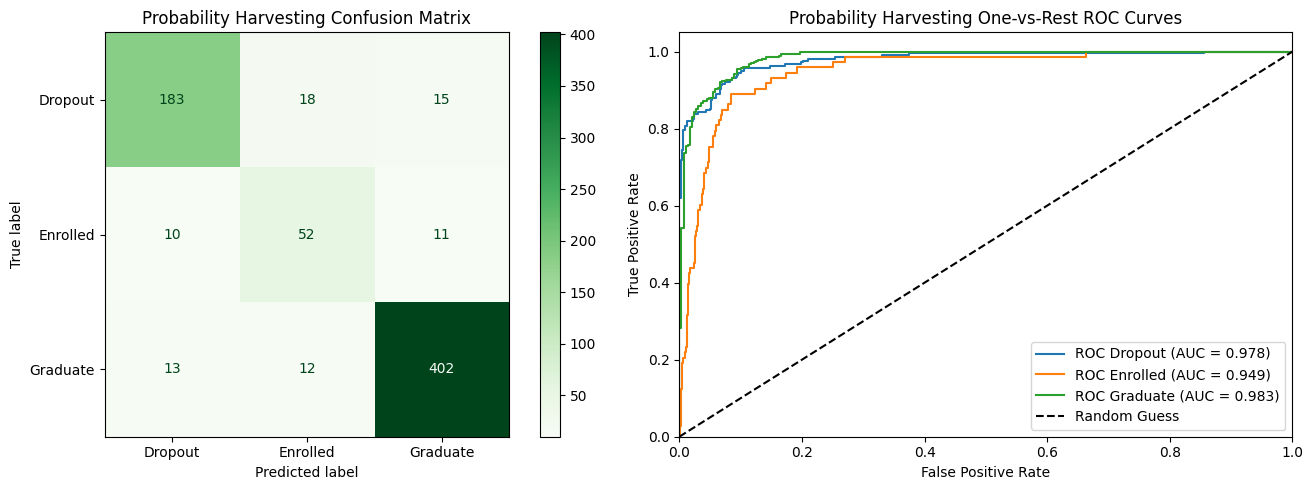

In [6]:
# import matplotlib.pyplot as plt 

# loss_harvest    = log_loss(y_test, harvest_proba)
# roc_auc_harvest = roc_auc_score(y_test, harvest_proba, multi_class='ovr', average='macro')

# print("="*60)
# print("TRADITIONAL ENSEMBLE BASELINE: PROBABILITY HARVESTING")
# print("="*60)
# print(f"Accuracy  : {accuracy_score(y_test, y_pred_harvest):.4f}")
# print(f"Log Loss  : {loss_harvest:.4f}")
# print(f"ROC-AUC   : {roc_auc_harvest:.4f} (One-vs-Rest Macro)")
# print("-" * 60)

# f1_h = f1_score(y_test, y_pred_harvest, average=None)
# print(f"F1 per class -> Dropout:{f1_h[0]:.4f}  Enrolled:{f1_h[1]:.4f}  Graduate:{f1_h[2]:.4f}")
# print(f"F1 Macro     : {f1_score(y_test, y_pred_harvest, average='macro'):.4f}")
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred_harvest, target_names=TARGET_NAMES))

# cm = confusion_matrix(y_test, y_pred_harvest)
# fig, ax = plt.subplots(figsize=(6, 5))
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TARGET_NAMES)
# disp.plot(cmap=plt.cm.Greens, ax=ax, values_format='d') 
# ax.set_title("Probability Harvesting Confusion Matrix")

# plt.tight_layout()
# plt.savefig('../output/probability_harvesting_confusion_matrix.png', dpi=150, bbox_inches='tight')
# plt.show()

from sklearn.metrics import log_loss, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt 
import pandas as pd

# 1. Perhitungan Metrics Evaluasi
loss_harvest    = log_loss(y_test, harvest_proba)
roc_auc_harvest = roc_auc_score(y_test, harvest_proba, multi_class='ovr', average='macro')

# 2. Cetak Ringkasan Performa di Konsol
print("="*60)
print("TRADITIONAL ENSEMBLE BASELINE: PROBABILITY HARVESTING")
print("="*60)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_harvest):.4f}")
print(f"Log Loss  : {loss_harvest:.4f}")
print(f"ROC-AUC   : {roc_auc_harvest:.4f} (One-vs-Rest Macro)")
print("-" * 60)

f1_h = f1_score(y_test, y_pred_harvest, average=None)
print(f"F1 per class -> Dropout:{f1_h[0]:.4f}  Enrolled:{f1_h[1]:.4f}  Graduate:{f1_h[2]:.4f}")
print(f"F1 Macro     : {f1_score(y_test, y_pred_harvest, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_harvest, target_names=TARGET_NAMES))
print("-" * 60)

# 3. Inisialisasi Kanvas Plot Berdampingan (1 Baris, 2 Kolom)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 0 (Kiri): Confusion Matrix
cm = confusion_matrix(y_test, y_pred_harvest)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TARGET_NAMES)
disp.plot(cmap=plt.cm.Greens, ax=axes[0], values_format='d') 
axes[0].set_title("Probability Harvesting Confusion Matrix")

# Subplot 1 (Kanan): One-vs-Rest ROC Curves
y_test_bin = pd.get_dummies(y_test).values
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], harvest_proba[:, i])
    roc_auc     = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f'ROC {TARGET_NAMES[i]} (AUC = {roc_auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', label='Random Guess')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Probability Harvesting One-vs-Rest ROC Curves')
axes[1].legend(loc="lower right")

# 4. Finalisasi Layout dan Penyimpanan Gambar Gabungan
plt.tight_layout()
plt.savefig('../output/probability_harvesting_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# from sklearn.metrics import roc_curve, auc
# import matplotlib.pyplot as plt 

# y_test_bin = pd.get_dummies(y_test).values

# fig, ax = plt.subplots(figsize=(7, 5))

# for i in range(3):
#     fpr, tpr, _ = roc_curve(y_test_bin[:, i], harvest_proba[:, i])
#     roc_auc     = auc(fpr, tpr)
#     ax.plot(fpr, tpr, label=f'ROC {TARGET_NAMES[i]} (AUC = {roc_auc:.3f})')

# ax.plot([0, 1], [0, 1], 'k--', label='Random Guess')
# ax.set_xlim([0.0, 1.0])
# ax.set_ylim([0.0, 1.05])
# ax.set_xlabel('False Positive Rate')
# ax.set_ylabel('True Positive Rate')
# ax.set_title('Probability Harvesting One-vs-Rest ROC Curves')
# ax.legend(loc="lower right")

# plt.tight_layout()

# plt.savefig('../output/probability_harvesting_roc_curve.png', dpi=150, bbox_inches='tight')
# plt.show()


In [8]:
import joblib

probability_harvesting_data = {
    'harvest_proba': harvest_proba,
    'y_pred_harvest': y_pred_harvest,
    'y_test': y_test,
    'target_names': TARGET_NAMES
}

joblib.dump(probability_harvesting_data, '../models/baseline_probability_harvesting.pkl')


['../models/baseline_probability_harvesting.pkl']